# TFR pipeline на реальных данных (`lib.*`)

Ноутбук воспроизводит refactored-пайплайн на реальном `tfr_*.fif`:

- загрузка данных как в `transformer_17_03_26.ipynb` (`read_tfrs` -> `y` из `events[:, 2]` -> crop/normalization)
- запуск Optuna через `lib.optuna.*` с хранением trial'ов в SQLite
- сохранение `y_true` / `y_hat` по каждому CV-фолду для последующего анализа

Базы Optuna сохраняются в папку с текущей датой внутри корневой папки данных.

In [ ]:
%load_ext autoreload
%autoreload 2

import gc
import json
import sys
from datetime import date
from pathlib import Path

import mne
import numpy as np
import optuna
import torch
import yaml
from torch.utils.data import DataLoader

root = Path.cwd().resolve().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from lib.data import TFRDataset
from lib.models.alexnet import AlexNetTFR
from lib.models.tfr_transformer import TFRTransformerWrapper
from lib.optuna import (
    attrs_fn,
    loss_slope,
    make_objective_engine,
    make_splits_fn_factory,
    objectives_fn,
    params_fn_factory,
    params_fn_factory_transformer,
    run_fold_fn_factory,
)
from lib.training.epochs import eval_one_epoch_f1_macro, train_one_epoch
from lib.data.normalisation import normalize_tfr_robust

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("project root:", root)
print("device:", device)

## 1. Загрузка реальных данных (`tfr_*.fif`) + папка БД с сегодняшней датой

In [ ]:
# Ожидаем структуру:
#   ├─ NeuronDeCo/
#   │   ├─ patients.yaml
#   │   └─ notebooks/
# PreprocessedData/

#   └─ specs_with_car/
#       └─ tfr_s11.fif

# Рабочая директория: .../Pirogov/NeuronDeCo/notebooks
NB_DIR = Path.cwd().resolve()
PROJECT_ROOT = NB_DIR.parent
PIROGOV_ROOT = PROJECT_ROOT.parent
PREPROCESSED_ROOT = PIROGOV_ROOT / "PreprocessedData"

patients_candidates = [
    PREPROCESSED_ROOT / "patients.yaml",  # приоритет: как вы просили
    PROJECT_ROOT / "patients.yaml",       # fallback на старый вариант
]
patients_yaml = next((p for p in patients_candidates if p.exists()), None)
if patients_yaml is None:
    raise FileNotFoundError(
        "patients.yaml not found. Checked: " + ", ".join(str(p) for p in patients_candidates)
    )

with open(patients_yaml, encoding="utf-8") as f:
    test = yaml.safe_load(f)
pat_config = test["default"]

# time_frequency_file = Path(pat_config["time_frequency_file"])
tfr_candidates = [
    PREPROCESSED_ROOT / "specs_with_car" / "tfr_s11.fif",  # приоритет: PreprocessedData
    PROJECT_ROOT / "specs_with_car" / "tfr_s11.fif",       # fallback
]
time_frequency_file = next((p for p in tfr_candidates if p.exists()), None)
if time_frequency_file is None:
    raise FileNotFoundError(
        "TFR file not found. Checked: " + ", ".join(str(p) for p in tfr_candidates)
    )

min_f, max_f, min_t, max_t = (
    pat_config["min_f"],
    pat_config["max_f"],
    pat_config["min_t"],
    pat_config["max_t"],
)

DATA_ROOT = time_frequency_file.parent
DATE_TAG = date.today().isoformat()
OPTUNA_DB_DIR = DATA_ROOT / DATE_TAG
OPTUNA_DB_DIR.mkdir(parents=True, exist_ok=True)

print("notebooks dir:", NB_DIR)
print("Pirogov root:", PIROGOV_ROOT)
print("PreprocessedData root:", PREPROCESSED_ROOT)
print("patients.yaml:", patients_yaml)
print("TFR file:", time_frequency_file)
print("Optuna DB dir:", OPTUNA_DB_DIR)
print("config slices:", (min_f, max_f, min_t, max_t))

tfr = mne.time_frequency.read_tfrs(str(time_frequency_file))[0]
y = np.where(tfr.events[:, 2] == 9, 1, 0).astype(np.int64)

# X = normalize_tfr_robust(tfr.crop(tmin=0.0, tmax=1.0).data)[:, :, min_f:max_f, min_t:max_t]
X = normalize_tfr_robust(tfr.crop(tmin=0.0, tmax=1.0).data)[:, :, :-50, :].astype(np.float32)

del tfr
gc.collect()  # Теперь память гарантировано свободна

n, c, f, t = X.shape
num_classes = int(np.unique(y).shape[0])
print("X shape:", X.shape)
print("y shape:", y.shape)
print("num_classes:", num_classes)

## 2. Optuna (AlexNet) c сохранением в SQLite

In [ ]:
seed = 42
cv = True
test_size = 0.2
cv_aggregate = "median"
max_epochs = 100
patience = 6
n_trials = 30

In [ ]:


alex_db = OPTUNA_DB_DIR / f"{time_frequency_file.stem}_alexnet.db"
alex_storage = f"sqlite:///{alex_db}"

objective_alex = make_objective_engine(
    X=X,
    y=y,
    make_splits_fn=make_splits_fn_factory(test_size=test_size, seed=seed, cv=cv),
    run_fold_fn=run_fold_fn_factory(
        ModelCls=AlexNetTFR,
        device=device,
        max_epochs=max_epochs,
        patience=patience,
        TFRDataset=TFRDataset,
        DataLoader=DataLoader,
        train_one_epoch=train_one_epoch,
        eval_one_epoch_f1_macro=eval_one_epoch_f1_macro,
        loss_metric=loss_slope,
    ),
    aggregate_mode=cv_aggregate,
    params_fn=params_fn_factory(in_channels=c, num_classes=num_classes),
    objectives_fn=objectives_fn,
    attrs_fn=attrs_fn,
)

study_a = optuna.create_study(
    directions=["maximize", "minimize"],
    sampler=optuna.samplers.NSGAIISampler(seed=seed),
    storage=alex_storage,
    study_name=f"{time_frequency_file.stem}_alexnet",
    load_if_exists=True,
)
study_a.optimize(objective_alex, n_trials=n_trials, show_progress_bar=True)

print("AlexNet DB:", alex_db)
study_a.best_trials[0].values, study_a.best_trials[0].params

## 3. Optuna (Transformer) c сохранением в SQLite

In [ ]:
tr_db = OPTUNA_DB_DIR / f"{time_frequency_file.stem}_transformer.db"
tr_storage = f"sqlite:///{tr_db}"

objective_tr = make_objective_engine(
    X=X,
    y=y,
    make_splits_fn=make_splits_fn_factory(test_size=test_size, seed=seed, cv=cv),
    run_fold_fn=run_fold_fn_factory(
        ModelCls=TFRTransformerWrapper,
        device=device,
        max_epochs=max_epochs,
        patience=patience,
        TFRDataset=TFRDataset,
        DataLoader=DataLoader,
        train_one_epoch=train_one_epoch,
        eval_one_epoch_f1_macro=eval_one_epoch_f1_macro,
        loss_metric=loss_slope,
    ),
    aggregate_mode=cv_aggregate,
    params_fn=params_fn_factory_transformer(
        num_classes=num_classes,
        seq_len=t,
    ),
    objectives_fn=objectives_fn,
    attrs_fn=attrs_fn,
)

study_t = optuna.create_study(
    directions=["maximize", "minimize"],
    sampler=optuna.samplers.NSGAIISampler(seed=seed + 1),
    storage=tr_storage,
    study_name=f"{time_frequency_file.stem}_transformer",
    load_if_exists=True,
)
study_t.optimize(objective_tr, n_trials=n_trials, show_progress_bar=True)

print("Transformer DB:", tr_db)
study_t.best_trials[0].values, study_t.best_trials[0].params

Trial number: 5
Values (f1, slope): [0.7128205128205127, -0.8437796188123308]
Params: {'batch_size': 16, 'dropout': 0.6642198760773332, 'lr': 0.002465969117210482, 'weight_decay': 0.0017123375973163992}


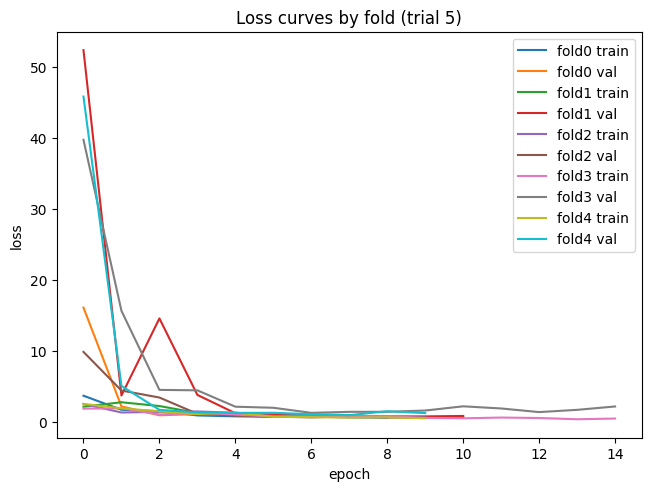

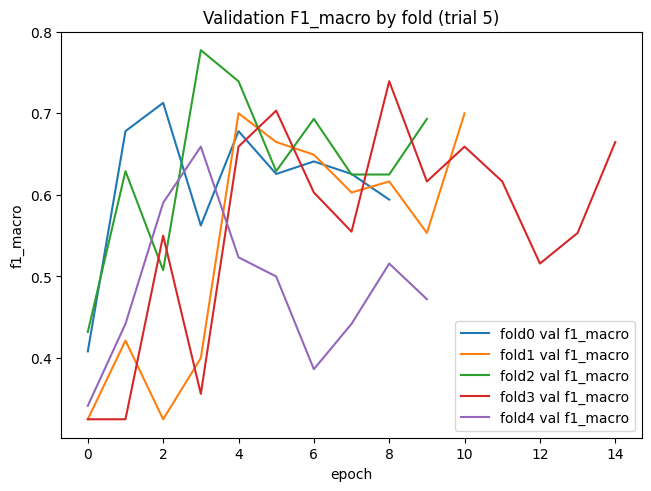

In [ ]:
import matplotlib.pyplot as plt

t = study_a.trials[5]  # если номера идут подряд, ок
# более надёжно, если есть пропуски:
# t = next(tr for tr in study.get_trials(deepcopy=False) if tr.number == trial_number)

print("Trial number:", t.number)
print("Values (f1, slope):", t.values)
print("Params:", t.params)

# --- новая номенклатура: fold_curves ---
fold_curves = t.user_attrs.get("fold_curves", None)

if fold_curves is not None and len(fold_curves) > 0:
    # 1) Loss curves по фолдам
    plt.figure(constrained_layout=True)
    for fc in fold_curves:
        name = fc.get("split", "fold")
        tr_losses = fc.get("train_losses", [])
        va_losses = fc.get("val_losses", [])
        if tr_losses:
            plt.plot(tr_losses, label=f"{name} train")
        if va_losses:
            plt.plot(va_losses, label=f"{name} val")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"Loss curves by fold (trial {t.number})")
    plt.legend()
    plt.show()

    # 2) F1 curves по фолдам
    plt.figure(constrained_layout=True)
    for fc in fold_curves:
        name = fc.get("split", "fold")
        va_f1s = fc.get("val_f1s", [])
        if va_f1s:
            plt.plot(va_f1s, label=f"{name} val f1_macro")
    plt.xlabel("epoch")
    plt.ylabel("f1_macro")
    plt.title(f"Validation F1_macro by fold (trial {t.number})")
    plt.legend()
    plt.show()

else:
    # --- fallback: старая номенклатура ---
    train_losses = t.user_attrs.get("train_losses", [])
    val_losses   = t.user_attrs.get("val_losses", [])
    val_f1s      = t.user_attrs.get("val_f1s", [])

    plt.figure(constrained_layout=True)
    if train_losses:
        plt.plot(train_losses, label="train loss")
    if val_losses:
        plt.plot(val_losses, label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"Loss curves (trial {t.number})")
    plt.legend()
    plt.show()

    plt.figure(constrained_layout=True)
    if val_f1s:
        plt.plot(val_f1s, label="val f1_macro")
    plt.xlabel("epoch")
    plt.ylabel("f1_macro")
    plt.title(f"Validation F1_macro (trial {t.number})")
    plt.legend()
    plt.show()

Trial number: 26
Values (f1, slope): [0.7698863636363636, -0.0015640685052582938]
Params: {'embed_dim': 128, 'preprocess': 'flatten', 'batch_size': 32, 'nhead': 4, 'dim_fc': 256, 'num_layers': 3, 'dropout': 0.19329182849319515, 'pooling': 'softmax', 'lr': 0.00021469229796692218, 'weight_decay': 1.0781126047243863e-06}


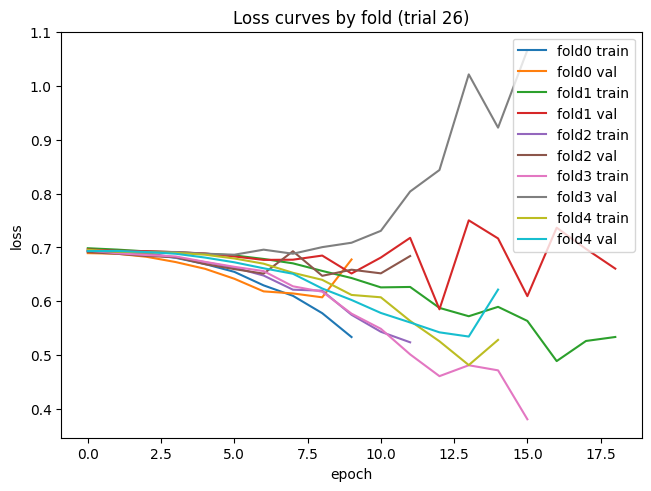

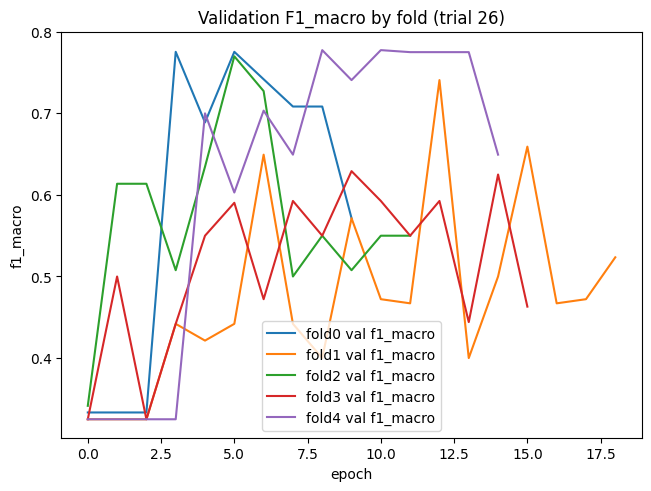

In [ ]:
import matplotlib.pyplot as plt

t = study_t.trials[26]  # если номера идут подряд, ок
# более надёжно, если есть пропуски:
# t = next(tr for tr in study.get_trials(deepcopy=False) if tr.number == trial_number)

print("Trial number:", t.number)
print("Values (f1, slope):", t.values)
print("Params:", t.params)

# --- новая номенклатура: fold_curves ---
fold_curves = t.user_attrs.get("fold_curves", None)

if fold_curves is not None and len(fold_curves) > 0:
    # 1) Loss curves по фолдам
    plt.figure(constrained_layout=True)
    for fc in fold_curves:
        name = fc.get("split", "fold")
        tr_losses = fc.get("train_losses", [])
        va_losses = fc.get("val_losses", [])
        if tr_losses:
            plt.plot(tr_losses, label=f"{name} train")
        if va_losses:
            plt.plot(va_losses, label=f"{name} val")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"Loss curves by fold (trial {t.number})")
    plt.legend()
    plt.show()

    # 2) F1 curves по фолдам
    plt.figure(constrained_layout=True)
    for fc in fold_curves:
        name = fc.get("split", "fold")
        va_f1s = fc.get("val_f1s", [])
        if va_f1s:
            plt.plot(va_f1s, label=f"{name} val f1_macro")
    plt.xlabel("epoch")
    plt.ylabel("f1_macro")
    plt.title(f"Validation F1_macro by fold (trial {t.number})")
    plt.legend()
    plt.show()

else:
    # --- fallback: старая номенклатура ---
    train_losses = t.user_attrs.get("train_losses", [])
    val_losses   = t.user_attrs.get("val_losses", [])
    val_f1s      = t.user_attrs.get("val_f1s", [])

    plt.figure(constrained_layout=True)
    if train_losses:
        plt.plot(train_losses, label="train loss")
    if val_losses:
        plt.plot(val_losses, label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"Loss curves (trial {t.number})")
    plt.legend()
    plt.show()

    plt.figure(constrained_layout=True)
    if val_f1s:
        plt.plot(val_f1s, label="val f1_macro")
    plt.xlabel("epoch")
    plt.ylabel("f1_macro")
    plt.title(f"Validation F1_macro (trial {t.number})")
    plt.legend()
    plt.show()

## 4. Сохранение `y_true` / `y_hat` по каждому CV-фолду

In [ ]:
def pick_best_trial(study: optuna.Study):
    # Для multi-objective выбираем trial с максимальным f1 и затем минимальным slope
    complete = [t for t in study.trials if t.values is not None]
    if not complete:
        raise RuntimeError("No complete trials in study")
    return sorted(complete, key=lambda tr: (-tr.values[0], tr.values[1]))[0]


@torch.no_grad()
def predict_fold(model, loader, device):
    model.eval()
    y_true, y_hat = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        pred = logits.argmax(dim=1).cpu().numpy()
        y_hat.append(pred)
        y_true.append(yb.cpu().numpy())
    return np.concatenate(y_true), np.concatenate(y_hat)


def _restore_model_params_for_runtime(model_params: dict):
    params = dict(model_params)

    pooling = params.get("pooling")
    if isinstance(pooling, dict) and pooling.get("type") == "SeqPool":
        params["pooling"] = pooling.get("mode", "mean")

    preprocess = params.get("preprocess")
    if isinstance(preprocess, dict):
        preprocess_type_to_key = {
            "TFRToSeqFlatten": "flatten",
            "TFRToSeqChannelConvCollapse": "channel_conv",
            "TFRToSeqFTPlaneConvCollapse": "ft_plane_conv",
            "TFRToSeqPixelWeightCollapse": "pixel_weight",
        }
        p_type = preprocess.get("type")
        if p_type in preprocess_type_to_key:
            params["preprocess"] = preprocess_type_to_key[p_type]
            if p_type == "TFRToSeqFTPlaneConvCollapse":
                if "kernel_freq" in preprocess:
                    params["kernel_freq"] = int(preprocess["kernel_freq"])
                if "kernel_time" in preprocess:
                    params["kernel_time"] = int(preprocess["kernel_time"])

    return params


def collect_cv_predictions(ModelCls, best_params, *, file_tag: str):
    splits = make_splits_fn_factory(test_size=test_size, seed=seed, cv=True)(X, y)
    out = {
        "file": str(time_frequency_file),
        "model": file_tag,
        "seed": seed,
        "folds": [],
    }

    for sp in splits:
        p_tr_ds = best_params["tr_dataset"]
        p_vl_ds = best_params["vl_dataset"]
        p_tr_ld = best_params["tr_loader"]
        p_vl_ld = best_params["vl_loader"]

        train_ds = TFRDataset(sp.X_train, sp.y_train, **p_tr_ds)
        val_ds = TFRDataset(sp.X_val, sp.y_val, **p_vl_ds)
        train_loader = DataLoader(train_ds, **p_tr_ld)
        val_loader = DataLoader(val_ds, **p_vl_ld)

        model_kwargs = _restore_model_params_for_runtime(best_params["model"])
        model = ModelCls(**model_kwargs).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), **best_params["optimizer"])

        best_f1 = -1.0
        bad = 0
        for _epoch in range(max_epochs):
            _ = train_one_epoch(model, train_loader, optimizer, device)
            _, va_f1 = eval_one_epoch_f1_macro(model, val_loader, device)
            if va_f1 > best_f1:
                best_f1 = float(va_f1)
                bad = 0
            else:
                bad += 1
                if bad >= patience:
                    break

        y_true_fold, y_hat_fold = predict_fold(model, val_loader, device)
        out["folds"].append(
            {
                "split": sp.name,
                "best_f1": best_f1,
                "y_true": y_true_fold.tolist(),
                "y_hat": y_hat_fold.tolist(),
            }
        )

    save_path = OPTUNA_DB_DIR / f"{time_frequency_file.stem}_{file_tag}_cv_predictions.json"
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(out, f, ensure_ascii=False, indent=2)

    return save_path, out


best_a = pick_best_trial(study_a)
best_t = study_t.trials[26]

pred_path_a, pred_data_a = collect_cv_predictions(
    AlexNetTFR,
    best_a.user_attrs["params"],
    file_tag="alexnet",
)
pred_path_t, pred_data_t = collect_cv_predictions(
    TFRTransformerWrapper,
    best_t.user_attrs["params"],
    file_tag="transformer",
)

print("Saved:", pred_path_a)
print("Saved:", pred_path_t)
print("AlexNet folds:", len(pred_data_a["folds"]))
print("Transformer folds:", len(pred_data_t["folds"]))

In [20]:
from pathlib import Path
import json
import numpy as np
from sklearn.metrics import confusion_matrix


def normalize_cm_rows(cm: np.ndarray) -> np.ndarray:
    """
    Нормировка confusion matrix по строкам:
    каждая строка = 100% истинного класса.
    """
    cm = cm.astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    return np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0) * 100.0


def print_matrix(mat: np.ndarray, digits: int = 2):
    """
    Красивый вывод матрицы.
    Для int печатает как есть, для float — с округлением.
    """
    if np.issubdtype(mat.dtype, np.integer):
        print(mat)
    else:
        with np.printoptions(precision=digits, suppress=True):
            print(mat)


def print_confusion_from_json(json_path):
    json_path = Path(json_path)
    with open(json_path, "r", encoding="utf-8") as f:
        payload = json.load(f)

    print(f"\n=== Confusion matrices: {json_path.name} ===")

    folds = payload.get("folds", [])
    if not folds:
        print("No folds found.")
        return

    # Общий набор меток по всем фолдам, чтобы все матрицы были одной формы
    global_labels = sorted(
        set(
            label
            for fold in folds
            for label in (fold["y_true"] + fold["y_hat"])
        )
    )

    all_true, all_hat = [], []
    fold_cms_abs = []
    fold_cms_pct = []

    for fold in folds:
        y_true = np.asarray(fold["y_true"], dtype=np.int64)
        y_hat = np.asarray(fold["y_hat"], dtype=np.int64)

        cm_abs = confusion_matrix(y_true, y_hat, labels=global_labels)
        cm_pct = normalize_cm_rows(cm_abs)

        fold_cms_abs.append(cm_abs)
        fold_cms_pct.append(cm_pct)

        all_true.append(y_true)
        all_hat.append(y_hat)

        print(f"\n[{fold['split']}] labels={global_labels}")

        print("\nAbsolute:")
        print_matrix(cm_abs)

        print("\nRow-normalized (%):")
        print_matrix(cm_pct)

    # Общая матрица по всем предсказаниям
    y_true_all = np.concatenate(all_true)
    y_hat_all = np.concatenate(all_hat)

    cm_all_abs = confusion_matrix(y_true_all, y_hat_all, labels=global_labels)
    cm_all_pct = normalize_cm_rows(cm_all_abs)

    # Среднее по фолдам
    mean_cm_abs = np.mean(np.stack(fold_cms_abs, axis=0), axis=0)
    mean_cm_pct = np.mean(np.stack(fold_cms_pct, axis=0), axis=0)

    print(f"\n[ALL FOLDS MERGED] labels={global_labels}")

    print("\nAbsolute:")
    print_matrix(cm_all_abs)

    print("\nRow-normalized (%):")
    print_matrix(cm_all_pct)

    print("\nMean absolute per fold:")
    print_matrix(mean_cm_abs)


print_confusion_from_json(pred_path_a)
print_confusion_from_json(pred_path_t)


=== Confusion matrices: tfr_s11_alexnet_cv_predictions.json ===

[fold0] labels=[0, 1]

Absolute:
[[10  4]
 [ 2 12]]

Row-normalized (%):
[[71.43 28.57]
 [14.29 85.71]]

[fold1] labels=[0, 1]

Absolute:
[[ 6  7]
 [ 2 12]]

Row-normalized (%):
[[46.15 53.85]
 [14.29 85.71]]

[fold2] labels=[0, 1]

Absolute:
[[ 9  4]
 [ 3 11]]

Row-normalized (%):
[[69.23 30.77]
 [21.43 78.57]]

[fold3] labels=[0, 1]

Absolute:
[[ 0 13]
 [ 1 13]]

Row-normalized (%):
[[  0.   100.  ]
 [  7.14  92.86]]

[fold4] labels=[0, 1]

Absolute:
[[5 9]
 [4 9]]

Row-normalized (%):
[[35.71 64.29]
 [30.77 69.23]]

[ALL FOLDS MERGED] labels=[0, 1]

Absolute:
[[30 37]
 [12 57]]

Row-normalized (%):
[[44.78 55.22]
 [17.39 82.61]]

Mean absolute per fold:
[[ 6.   7.4]
 [ 2.4 11.4]]

=== Confusion matrices: tfr_s11_transformer_cv_predictions.json ===

[fold0] labels=[0, 1]

Absolute:
[[ 8  6]
 [ 1 13]]

Row-normalized (%):
[[57.14 42.86]
 [ 7.14 92.86]]

[fold1] labels=[0, 1]

Absolute:
[[ 6  7]
 [ 4 10]]

Row-normalized